In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy
from scipy.interpolate import interp1d
from scipy import special
import sys 

Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

#3ML https://threeml.readthedocs.io/en/latest/_modules/threeML/utils/OGIP/response.html
#https://github.com/threeML/cds_tutorial/blob/master/gen_spectra.py

In [2]:
Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar
Fit.query = "yes"  # automatically answer "yes" to prompts

# Checks of xspec

Here I load the data 

In [3]:
AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80_DECEMBER/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
fileIBLineTM1="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM1.txt"
Energy_width_TM1 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM1.csv"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
fileIBLineTM2="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM2.txt"
Energy_width_TM2 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM2.csv"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
fileIBLineTM3="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM3.txt"
Energy_width_TM3 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM3.csv"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
fileIBLineTM4="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM4.txt"
Energy_width_TM4 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM4.csv"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
fileIBLineTM5="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM5.txt"
Energy_width_TM5 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM5.csv"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
fileIBLineTM6="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM6.txt"
Energy_width_TM6 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM6.csv"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
fileIBLineTM7="/home/jortecal/GitHub/eRosita/IBLines/IBLine_TM7.txt"
Energy_width_TM7 = "/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM7.csv"


In [4]:
# Define telescope file mappings
telescope_files = {
    "TM1": (filespectrumTM1, fileRMFTM1, fileARFTM1, fileIBLineTM1, Energy_width_TM1),
    "TM2": (filespectrumTM2, fileRMFTM2, fileARFTM2, fileIBLineTM2, Energy_width_TM2),
    "TM3": (filespectrumTM3, fileRMFTM3, fileARFTM3, fileIBLineTM3, Energy_width_TM3),
    "TM4": (filespectrumTM4, fileRMFTM4, fileARFTM4, fileIBLineTM4, Energy_width_TM4),
    "TM5": (filespectrumTM5, fileRMFTM5, fileARFTM5, fileIBLineTM5, Energy_width_TM5),
    "TM6": (filespectrumTM6, fileRMFTM6, fileARFTM6, fileIBLineTM6, Energy_width_TM6),
    "TM7": (filespectrumTM7, fileRMFTM7, fileARFTM7, fileIBLineTM7, Energy_width_TM7),
    "ALL": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM5, filespectrumTM6, filespectrumTM7],
            [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM5, fileRMFTM6, fileRMFTM7],
            [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM5, fileARFTM6, fileARFTM7],
            [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM5, fileIBLineTM6, fileIBLineTM7],
            [Energy_width_TM1, Energy_width_TM2, Energy_width_TM3, Energy_width_TM4, Energy_width_TM5, Energy_width_TM6, Energy_width_TM7]),
    "ALL_CLEAN": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM6],
    [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM6],
    [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM6],
    [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM6],
    [Energy_width_TM1, Energy_width_TM2, Energy_width_TM3, Energy_width_TM4, Energy_width_TM6])
}

In [5]:
telescope = "TM1"

In [6]:
# Set the file arrays based on telescope selection
if telescope in telescope_files:
    if telescope == "ALL":
        vfilespectrum, vfileRMF, vfileARF, vfileIBLine, vEnergyWidth = telescope_files[telescope]
    else:
        spectrum_file, rmf_file, arf_file, ibline_file, energy_width_file = telescope_files[telescope]
        vfilespectrum = [spectrum_file]
        vfileRMF = [rmf_file]
        vfileARF = [arf_file]
        vfileIBLine = [ibline_file]
        vEnergyWidth = [energy_width_file]
    print(f"Using telescope: {telescope}")
    print(f"Number of telescopes: {len(vfilespectrum)}")
else:
    print(f"Error: Unknown telescope '{telescope}'. Valid options: TM1, TM2, TM3, TM4, TM5, TM6, TM7, ALL_CLEAN")
    sys.exit(1)

Using telescope: TM1
Number of telescopes: 1


In [7]:
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80_DECEMBER/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 3.608e+05 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80_DECEMBER/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Tele

Error: cannot read response file srctoolout_120_RMF_00001.fits


or Source 2



# Check about the effect of TBABS on line

Run the first cell above where you load the data and then the following ones.

Slighly modified from /Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_windows/Checks_EffectTBABSonLine.ipynb

The goal is to do some revision for referee report.

I consider a model with a line at a given energy multipied by a TBABS with nH value used in the v1 arxiv of the paper i.e. 0.22e22 cm-2. Consider another line at the same energy multipied by a TBABS with a different nH value. Pass the lines through the response function and do the ratio. Consider bins +- 5 sigma around the line. Obviously the ratio slighly changes depending on the energy bin considered. 
I provide the ratio at the center (should be the peak), and in some other points, see below.


In [12]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/Energy_width/Energ_Width_TM1.csv", usecols=(0, 1))
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.0 #

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)

Eline  1.0  sigma  0.029619317782370886
Emin  0.8519034110881456  Emax  1.1480965889118544
**-0.8519,,1.1481-**
   129 channels (1-129) ignored in spectrum #     1
   854 channels (171-1024) ignored in spectrum #     1



In [13]:
AllModels.clear()
Xset.chatter = 0
Modeltest = Model("tbabs*(gaussian)+tbabs*(gaussian)", "mpoly", 1)

Modeltest.TBabs.nH.values = 0.145 # 0.145
Modeltest.gaussian.LineE.values = float(Eline)
Modeltest.gaussian.norm.values = 0.01

Modeltest.TBabs_3.nH.values = 0.22 # 0.22 Value considered in v1 of the arXiv paper
Modeltest.gaussian_4.LineE.values = float(Eline)
Modeltest.gaussian_4.norm.values = 0.01

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.


In [14]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:TBabs<1>*gaussian<2> + TBabs<3>*gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.145000     +/-  0.0          
   2    2   gaussian   LineE      keV      1.00000      +/-  0.0          
   3    2   gaussian   Sigma      keV      0.100000     +/-  0.0          
   4    2   gaussian   norm                1.00000E-02  +/-  0.0          
   5    3   TBabs      nH         10^22    0.220000     +/-  0.0          
   6    4   gaussian   LineE      keV      1.00000      +/-  0.0          
   7    4   gaussian   Sigma      keV      0.100000     +/-  0.0          
   8    4   gaussian   norm                1.00000E-02  +/-  0.0          
________________________________________________________________________



Plot command list is now empty
nAddComps  2


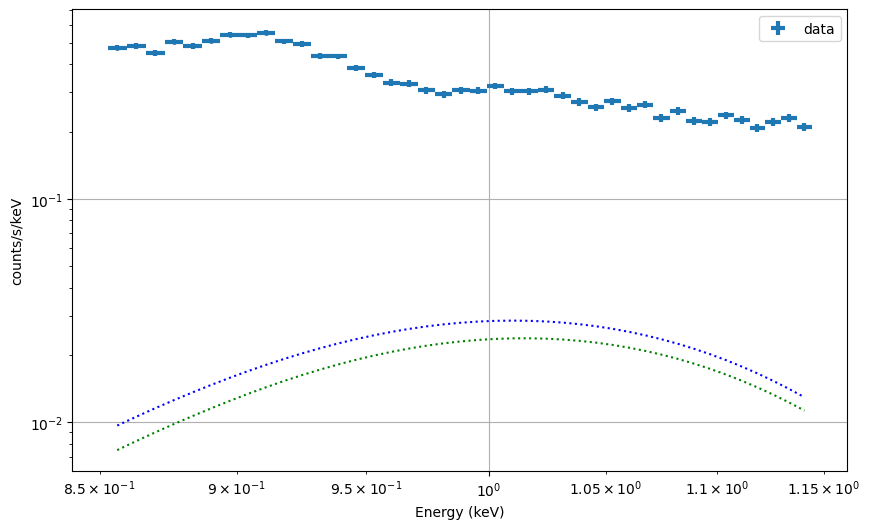

In [15]:

Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)


modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)



# 
#for i in range(0,nAddComps):
#    print(i)
ax.plot(energiesTMi, modelcomp[0][:],label='',linestyle=':', marker='',color='blue')
ax.plot(energiesTMi, modelcomp[1][:],label='',linestyle=':', marker='',color='green')


#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [16]:
print(modelcomp[0][:]/modelcomp[1][:])
mid = len(modelcomp[0]) // 2
delta = len(modelcomp[0]) // 10   # 1 sigma
ratio_max=np.max(modelcomp[0][:]/modelcomp[1][:])
ratio_min=np.min(modelcomp[0][:]/modelcomp[1][:])
ratio_mid = modelcomp[0][mid] / modelcomp[1][mid]
m1 = mid - 2*delta
ratio_m1 = modelcomp[0][m1] / modelcomp[1][m1]  # -2 sigma
p1 = mid + 2*delta
ratio_p1 = modelcomp[0][p1] / modelcomp[1][p1]  # -2 sigma

print("Energy at mid ",energiesTMi[mid])
print("mid min and max ",ratio_mid," ",ratio_min," ",ratio_max, " %max min",(ratio_max-ratio_min)*2/(ratio_max+ratio_min))
print("mid +- 1 sigma ",ratio_mid," ",ratio_m1," ",ratio_p1, " % ",(ratio_p1-ratio_m1)*2/(ratio_p1+ratio_m1))
print("Eline ",Eline," ratio_mid (Amplitude with TBABS)/(Amplitude with TBabs_3) ",ratio_mid, "and the inverse ",1./ratio_mid)
print(Eline,1./ratio_mid)

[1.28832709 1.28572695 1.28296754 1.27996278 1.27661987 1.27291311
 1.26886881 1.26455483 1.2600635  1.25547867 1.25086754 1.24628123
 1.24175091 1.23729387 1.23292231 1.22864034 1.22444835 1.22034858
 1.21633922 1.21241831 1.20858579 1.20483902 1.20117589 1.19759573
 1.19408591 1.19066265 1.18731859 1.18404964 1.18085369 1.17771541
 1.17466065 1.17167282 1.16874508 1.16587199 1.16306841 1.16031681
 1.15760688 1.15496266 1.15236106 1.1498078  1.14731433]
Energy at mid  0.9954912662506104
mid min and max  1.2085857946292788   1.1473143302232767   1.2883270876811799  %max min 0.11579106548387227
mid +- 1 sigma  1.2085857946292788   1.2417509139646268   1.1808536911458896  %  -0.0502741740771678
Eline  1.0  ratio_mid (Amplitude with TBABS)/(Amplitude with TBabs_3)  1.2085857946292788 and the inverse  0.8274133325443723
1.0 0.8274133325443723
